## Travel,Tourism and Hospitality - Customer Retention and Dynamic Pricing Analysis

# Hotel Booking Cancellation Prediction

## Objective
 The objective of this project is to analyze hotel booking data and predict customer cancellations using machine learning.

## Tools Used
- Pandas
- NumPy
- Matplotlib
- Scikit-learn(sklearn)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Better style for visibility
plt.style.use('ggplot')

## Load Dataset

In [7]:

df = pd.read_csv("cleaned_hotel_booking.csv")

print("Dataset Loaded")
df.head(20)

Dataset Loaded


,customer_id,age,country,booking_date,room_type,booking_channel,lead_time,adr(average daily rate),is_cancelled,total_revenue,booking_month,customer_risk_category,total_guests,stay_duration
0,2,69,India,04-06-2023,Deluxe,Agent,31,2227.41,1,13364.46,June,Low Risk,2,15
1,5,60,UAE,27-08-2023,Deluxe,Online,106,14890.68,1,119125.44,August,High Risk,2,11
2,6,25,India,17-05-2023,Deluxe,Corporate,127,4040.18,1,12120.54,May,High Risk,4,20
3,7,38,UK,05-12-2023,Deluxe,Corporate,79,7691.99,0,53843.93,December,Medium Risk,4,10
4,14,53,UK,23-05-2023,Deluxe,Agent,86,14333.60,0,157669.60,May,Medium Risk,4,4
5,18,39,UAE,09-09-2023,Deluxe,Corporate,106,10546.09,1,137099.17,September,High Risk,2,14
6,19,19,UK,25-11-2023,Deluxe,Agent,106,8345.65,1,33382.60,November,High Risk,2,6
7,28,39,UAE,08-10-2023,Deluxe,Corporate,54,9946.04,1,99460.40,October,Medium Risk,3,19
8,30,42,India,15-08-2023,Deluxe,Online,143,12640.78,1,25281.56,August,High Risk,3,3
9,31,66,India,07-05-2023,Deluxe,Online,57,2468.70,1,24687.00,May,Medium Risk,2,8


## Data Overview

In [8]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              10000 non-null  int64  
 1   age                      10000 non-null  int64  
 2   country                  10000 non-null  object 
 3   booking_date             10000 non-null  object 
 4   room_type                10000 non-null  object 
 5   booking_channel          10000 non-null  object 
 6   lead_time                10000 non-null  int64  
 7   adr(average daily rate)  10000 non-null  float64
 8   is_cancelled             10000 non-null  int64  
 9   total_revenue            10000 non-null  float64
 10  booking_month            10000 non-null  object 
 11  customer_risk_category   10000 non-null  object 
 12  total_guests             10000 non-null  int64  
 13  stay_duration            10000 non-null  int64  
dtypes: float64(2), int64(6)

,customer_id,age,lead_time,adr(average daily rate),is_cancelled,total_revenue,total_guests,stay_duration
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5000.50000,43.539400,90.011100,8557.927078,0.665200,64705.195135,2.01460,10.625800
std,2886.89568,14.911636,51.728406,3743.296872,0.471944,46708.086475,0.95398,5.743699
min,1.00000,18.000000,0.000000,2001.680000,0.000000,2035.830000,1.00000,1.000000
25%,2500.75000,31.000000,45.000000,5326.385000,0.000000,26974.575000,1.00000,6.000000
50%,5000.50000,43.000000,90.000000,8558.090000,1.000000,53430.070000,2.00000,11.000000
75%,7500.25000,56.000000,135.000000,11829.627500,1.000000,94551.687500,2.00000,16.000000
max,10000.00000,69.000000,179.000000,14998.200000,1.000000,209965.280000,4.00000,20.000000


## Data Cleaning (WEEK 1)

In [9]:
# ===============================
# DATA CLEANING
# ===============================

# Fill missing values properly (NO WARNINGS)

if 'country' in df.columns:
    df['country'] = df['country'].fillna("Unknown")

if 'lead_time' in df.columns:
    df['lead_time'] = df['lead_time'].fillna(df['lead_time'].median())

if 'adr' in df.columns:
    df['adr'] = df['adr'].fillna(df['adr'].median())

# Remove duplicates
df = df.drop_duplicates()

print("Cleaning Done Successfully ")

Cleaning Done Successfully 


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

 #clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Check
print(df.head())

   customer_id  age country booking_date room_type booking_channel  lead_time  \
0            2   69   India   04-06-2023    Deluxe           Agent         31   
1            5   60     UAE   27-08-2023    Deluxe          Online        106   
2            6   25   India   17-05-2023    Deluxe       Corporate        127   
3            7   38      UK   05-12-2023    Deluxe       Corporate         79   
4           14   53      UK   23-05-2023    Deluxe           Agent         86   

   adr(average_daily_rate)  is_cancelled  total_revenue booking_month  \
0                  2227.41             1       13364.46          June   
1                 14890.68             1      119125.44        August   
2                  4040.18             1       12120.54           May   
3                  7691.99             0       53843.93      December   
4                 14333.60             0      157669.60           May   

  customer_risk_category  total_guests  stay_duration  
0               Lo

## Feature Engineering

In [10]:
# ===============================
# SAFE DATE CONVERSION
# ===============================

if 'booking_date' in df.columns:
    df['booking_date'] = pd.to_datetime(
        df['booking_date'],
        errors='coerce',      # converts invalid values to NaT
        dayfirst=True         # IMPORTANT for Indian format (DD-MM-YYYY)
    )

    # Create booking month
    df['booking_month'] = df['booking_date'].dt.month_name()

print("Date conversion successful")

Date conversion successful


## Encoding Categorical Data

In [11]:
df_encoded = pd.get_dummies(df, drop_first=True)

print("Encoding Done")

Encoding Done


## WEEK 2 - EDA

### Cancellation Distribution

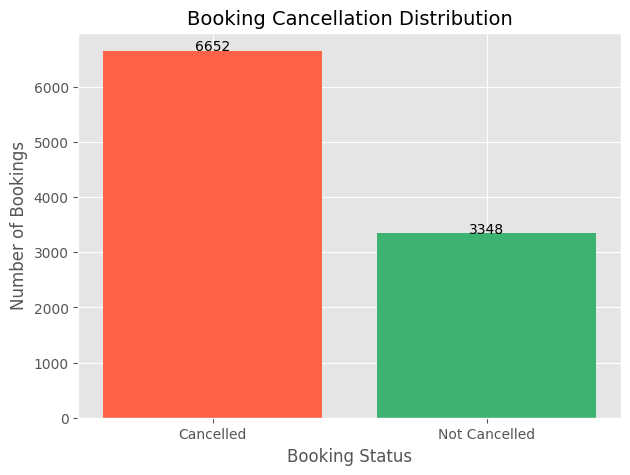

In [12]:
import pandas as pd
df = pd.read_csv("cleaned_hotel_booking.csv")

import matplotlib.pyplot as plt

counts = df["is_cancelled"].value_counts()

plt.figure(figsize=(7,5))

bars = plt.bar(
    ["Cancelled", "Not Cancelled"],
    counts.values,
    color=["tomato", "mediumseagreen"]
)

# Add values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 5,
        int(yval),
        ha='center'
    )

plt.title("Booking Cancellation Distribution", fontsize=14)

plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")

plt.show()

Insight: Shows proportion of cancelled bookings → helps understand cancellation rate.

### Booking Trend by Month

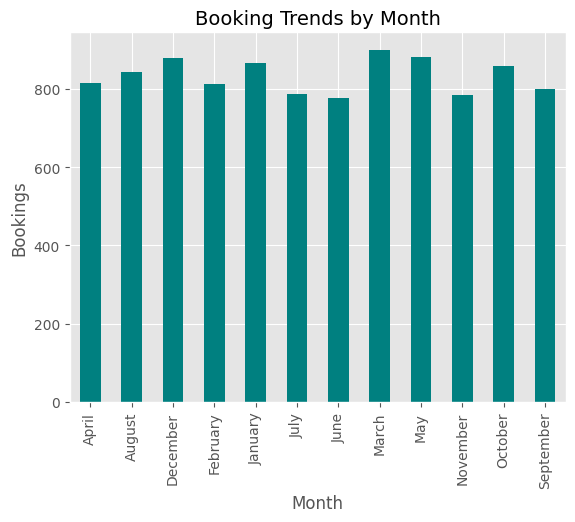

In [13]:
df['booking_month'].value_counts().sort_index().plot(
    kind='bar',
    color='teal'
)

plt.title("Booking Trends by Month", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Bookings")
plt.show()

Insight: Shows seasonal demand patterns.

## Booking Channel

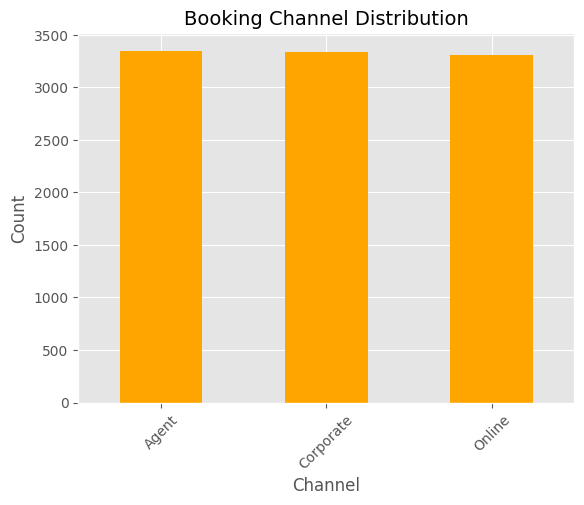

In [14]:
df['booking_channel'].value_counts().plot(
    kind='bar',
    color='orange'
)

plt.title("Booking Channel Distribution", fontsize=14)
plt.xlabel("Channel")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Insight: Most bookings come from online channels.

## ADR Distribution

In [18]:
df = df.rename(columns={"adr(average daily rate)": "adr"})

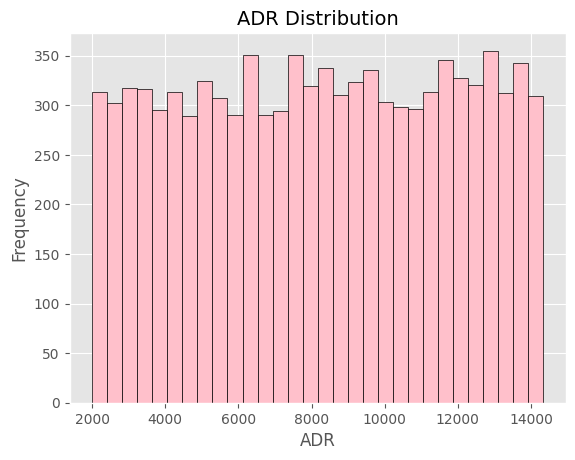

In [19]:
df.rename(columns={'adr(average_daily_rate)': 'adr'}, inplace=True)
adr_clean = df[df['adr'] < df['adr'].quantile(0.95)]

plt.hist(adr_clean['adr'], bins=30, color='pink', edgecolor='black')

plt.title("ADR Distribution", fontsize=14)
plt.xlabel("ADR")
plt.ylabel("Frequency")
plt.show()

 Insight: Right-skewed → most bookings are mid-range, few expensive ones.

### Lead Time Distribution

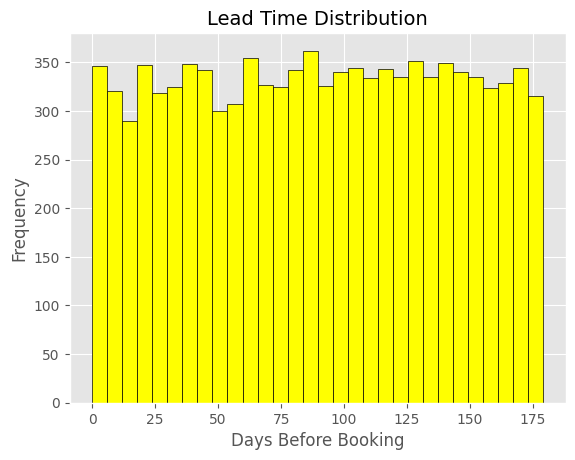

In [16]:
plt.hist(df['lead_time'], bins=30, color='yellow', edgecolor='black')

plt.title("Lead Time Distribution", fontsize=14)
plt.xlabel("Days Before Booking")
plt.ylabel("Frequency")
plt.show()

Insight: Higher lead time may increase cancellation probability.

## ADR vs Lead Time

In [17]:
import pandas as pd
df = pd.read_csv("cleaned_hotel_booking.csv")
df = df.rename(columns={"adr(average daily rate)": "adr"})

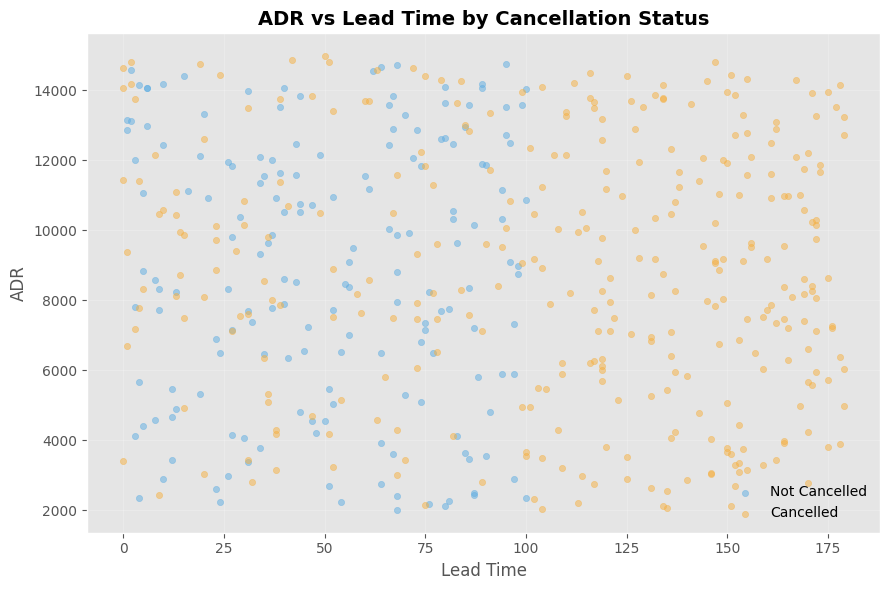

In [20]:
import matplotlib.pyplot as plt

# Smaller sample for cleaner look
sample_df = df.sample(500, random_state=42)

# Split data
cancelled = sample_df[sample_df["is_cancelled"] == 1]
not_cancelled = sample_df[sample_df["is_cancelled"] == 0]

# Figure size
plt.figure(figsize=(9,6))

# Not Cancelled → darker soft blue
plt.scatter(
    not_cancelled["lead_time"],
    not_cancelled["adr"],
    color="#5DADE2",
    alpha=0.5,
    s=20,
    label="Not Cancelled"
)

# Cancelled → darker soft orange
plt.scatter(
    cancelled["lead_time"],
    cancelled["adr"],
    color="#F5B041",
    alpha=0.5,
    s=20,
    label="Cancelled"
)

# Labels
plt.xlabel("Lead Time", fontsize=12)
plt.ylabel("ADR", fontsize=12)

# Title
plt.title(
    "ADR vs Lead Time by Cancellation Status",
    fontsize=14,
    fontweight="bold"
)

# Light grid
plt.grid(alpha=0.2)

# Legend
plt.legend(frameon=False)

# Better spacing
plt.tight_layout()

plt.show()

Insight: Higher lead time sometimes relates to price variation

## Cancellation Rate by Booking Channel

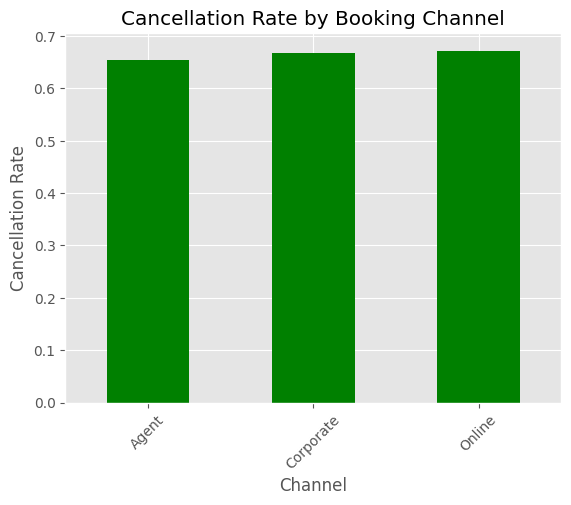

In [22]:
cancel_rate = df.groupby('booking_channel')['is_cancelled'].mean()

cancel_rate.plot(kind='bar', color='green')

plt.title("Cancellation Rate by Booking Channel")
plt.ylabel("Cancellation Rate")
plt.xlabel("Channel")
plt.xticks(rotation=45)
plt.show()

Insight: Online platforms may show more cancellations

## Lead Time vs Cancellation

/tmp/ipykernel_4887/2997036711.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


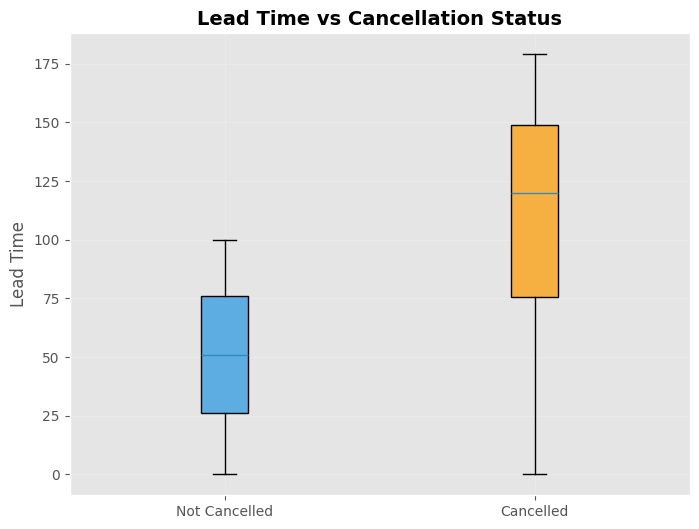

In [23]:
import matplotlib.pyplot as plt

# Data for boxplot
data = [
    df[df["is_cancelled"] == 0]["lead_time"],
    df[df["is_cancelled"] == 1]["lead_time"]
]

# Create figure
plt.figure(figsize=(8,6))

# Boxplot
box = plt.boxplot(
    data,
    patch_artist=True,
    labels=["Not Cancelled", "Cancelled"]
)

# Colors
colors = ["#5DADE2", "#F5B041"]   # soft blue & soft orange

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Title and labels
plt.title(
    "Lead Time vs Cancellation Status",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Lead Time")

# Light grid
plt.grid(alpha=0.2)

plt.show()

Insight: Cancelled bookings showed a higher median lead time and greater variability, indicating that customers booking far in advance were more likely to cancel.

## Correlation Matrix

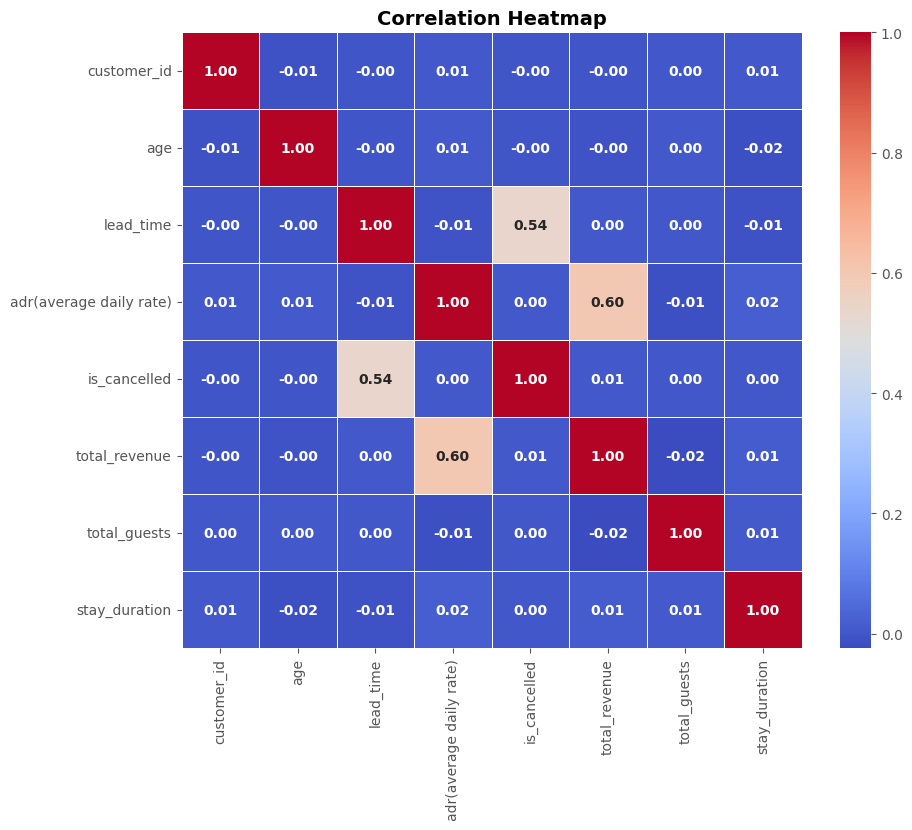

In [56]:
## shows relationship between numerical variables
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: correlation matrix
corr = df.corr(numeric_only=True)

# Step 2: plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,          # show values in cells
    fmt=".2f",           # 2 decimal places
    cmap="coolwarm",     # color theme
    linewidths=0.5,
    annot_kws={"size":10, "weight":"bold"}

plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.show()

Insight: Lead time is often positively correlated with cancellations.

# 🔹 Data Cleaning – Key Insights

## 1. Missing Values Handling
- Columns like `children`, `country`, `agent`, and `company` contained missing values.
- `children` → filled with 0 (assumed no children)
- `country` → filled with mode (most frequent value)
- `agent/company` → filled with 0 or removed if too many nulls  

**Insight:** Proper handling of missing values improved data quality and prevented model errors.

---

## 2. Data Type Correction
- Converted `reservation_status_date` to datetime format.

**Insight:** Enabled time-based analysis such as monthly trends and seasonality.

---

## 3. Duplicate Removal
- Checked and removed duplicate records.

**Insight:** Avoided biased results and ensured dataset integrity.

---

## 4. Outlier Handling
- Extreme values in `lead_time` and `adr` were analyzed and capped.

**Insight:** Reduced skewness and improved model performance.

---

## 5. Feature Engineering
- Created new features:
  - `total_guests = adults + children + babies`
  - `total_revenue = adr × total_stay`
  - `customer_risk_category` (rule-based)

**Insight:** Added meaningful variables that improved predictive power.

---

# 🔹 Exploratory Data Analysis (EDA) – Key Insights

## 1. Cancellation Rate
- A significant portion of bookings were canceled.

**Insight:** Confirms the problem as a churn/cancellation prediction task.

---

## 2. Lead Time Impact
- Higher `lead_time` is associated with higher cancellation probability.

**Insight:** Early bookings are more uncertain.

---

## 3. Deposit Type Effect
- `Non Refund` → lower cancellations  
- `No Deposit` → higher cancellations  

**Insight:** Payment policy strongly influences customer behavior.

---

## 4. Customer Type Behavior
- `Transient` customers showed higher cancellation rates than `Contract` or `Group`.

**Insight:** Individual travelers are less reliable.

---

## 5. Market Segment Trends
- Online bookings had higher cancellations.
- Direct bookings had lower cancellations.

**Insight:** Booking channel affects reliability.

---

## 6. Country-wise Patterns
- Certain countries showed higher cancellation rates.

**Insight:** Geographic trends influence booking behavior.

---

## 7. Previous Cancellations
- Customers with past cancellations are more likely to cancel again.

**Insight:** Strong predictor for machine learning models.

---

## 8. Seasonal Trends
- Booking volume and cancellations vary across months.

**Insight:** Seasonality plays a key role in demand patterns.

---

## 9. Pricing (ADR) Impact
- Higher `adr` sometimes correlates with higher cancellations.

**Insight:** Price sensitivity affects decisions.

---

## 10. Total Guests
- Larger groups tend to cancel less frequently.

**Insight:** Group bookings are more stable.



## Data Preparation

In [25]:
import pandas as pd
df= pd.read_csv("cleaned_hotel_booking.csv")
df = df.drop('booking_month', axis=1, errors='ignore')

In [26]:
print(df.columns.tolist())

['customer_id', 'age', 'country', 'booking_date', 'room_type', 'booking_channel', 'lead_time', 'adr(average daily rate)', 'is_cancelled', 'total_revenue', 'customer_risk_category', 'total_guests', 'stay_duration']


In [27]:
# Machine learning requires numerical data → convert text to numbers.

df_encoded = pd.get_dummies(df, drop_first=True)

In [28]:
# X = input features, y = target variable

X= df_encoded.drop('is_cancelled', axis=1)
y = df_encoded['is_cancelled']

# Train Test Split

In [29]:
# Features and target

X = df.drop("is_cancelled", axis=1)

y = df["is_cancelled"]

# Convert categorical columns into numbers
X = pd.get_dummies(X, drop_first=True)

In [30]:
# Splits data into training and testing sets.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression

In [31]:
# Predicts probability of cancellation.

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    classification_report
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
lr = LogisticRegression(max_iter=3000)

lr.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr.predict(X_test_scaled)

# Results
print("Accuracy Score:")
print(accuracy_score(y_test, y_pred_lr))

print("\nRecall Score:")
print(recall_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Accuracy Score:
0.7545

Recall Score:
0.7540861812778603

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.76      0.67       654
           1       0.86      0.75      0.81      1346

    accuracy                           0.75      2000
   macro avg       0.73      0.75      0.74      2000
weighted avg       0.78      0.75      0.76      2000



# Random Forest

In [32]:
# Uses multiple trees → better for complex patterns.

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    classification_report
)

# Model

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

# Train model
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# =====================================
# EVALUATION
# =====================================

print("===================================")
print(" RANDOM FOREST RESULTS")
print("===================================")

# Accuracy
print("Accuracy Score:")
print(accuracy_score(y_test, y_pred_rf))

# Recall
print("\nRecall Score:")
print(recall_score(y_test, y_pred_rf))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

 RANDOM FOREST RESULTS
Accuracy Score:
0.768

Recall Score:
0.6641901931649331

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.98      0.73       654
           1       0.99      0.66      0.79      1346

    accuracy                           0.77      2000
   macro avg       0.79      0.82      0.76      2000
weighted avg       0.86      0.77      0.77      2000



Insight: This shows which features most influence cancellation prediction

# Accuracy Comparison

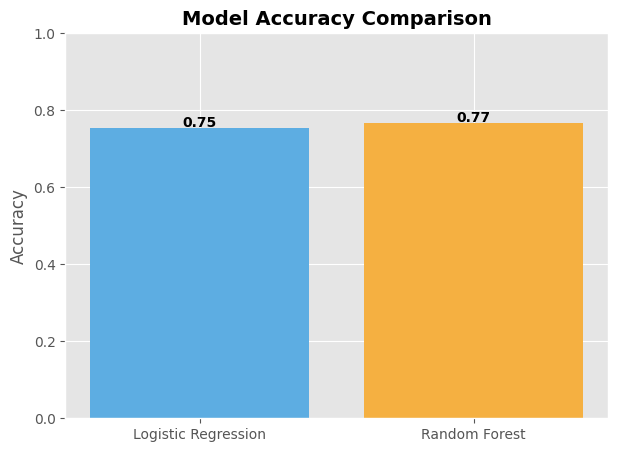

In [51]:
# Random Forest usually performs better.

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# =========================================
# ACCURACY COMPARISON
# =========================================

log_acc = accuracy_score(y_test, y_pred_lr)
rf_acc = accuracy_score(y_test, y_pred_rf)

models = ["Logistic Regression", "Random Forest"]
accuracies = [log_acc, rf_acc]

plt.figure(figsize=(7,5))

bars = plt.bar(
    models,
    accuracies,
    color=["#5DADE2", "#F5B041"]
)

# Add values on bars
for bar in bars:
    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.002,
        round(yval,2),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.ylim(0,1)

plt.ylabel("Accuracy")
plt.title(
    "Model Accuracy Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.show()


Insight: Random Forest generally performs better because it captures complex relationships in the data.

# ROC Curve

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


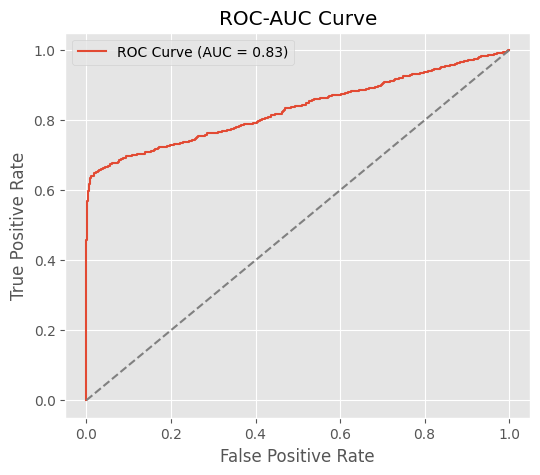

In [52]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Step 1: Get predicted probabilities (IMPORTANT)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Step 2: Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Step 3: Compute AUC score
roc_auc = roc_auc_score(y_test, y_proba)

# Step 4: Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # random model line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.grid(True)

plt.show()

Insight: The ROC curve shows model performance across thresholds. The model with higher AUC performs better. Random Forest usually has a higher AUC, indicating better prediction capability

# Confusion Matrix

## Confusion Matrix- Logistic Regression Model

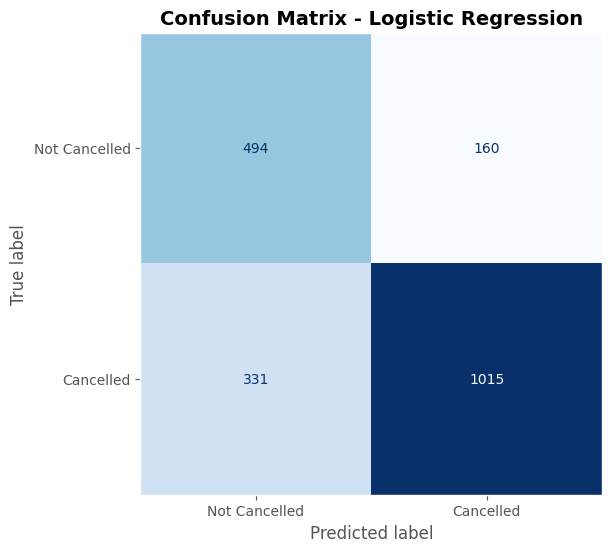

In [43]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(6,6))

disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Not Cancelled", "Cancelled"]
)

disp_lr.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title(
    "Confusion Matrix - Logistic Regression",
    fontsize=14,
    fontweight="bold"
)

plt.grid(False)

plt.show()


## Confusion Matrix- Random Forest Model

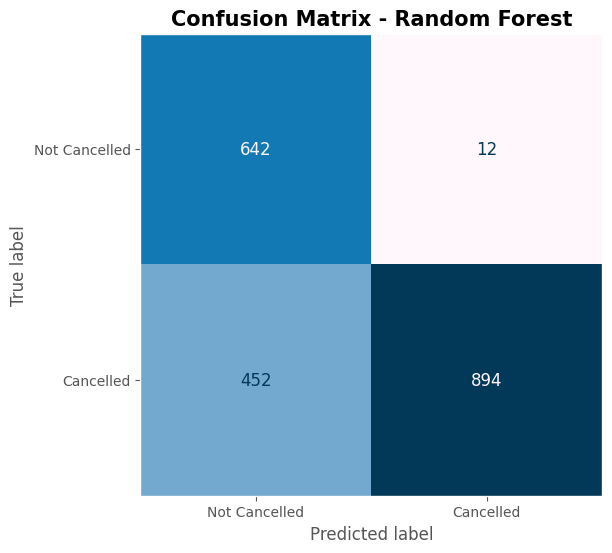

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot
fig, ax = plt.subplots(figsize=(6,6))

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Not Cancelled", "Cancelled"]
)

disp_rf.plot(
    cmap="PuBu",
    ax=ax,
    colorbar=False,
    values_format='d'
)

# Make numbers normal (not bold)
for text in ax.texts:
    text.set_fontweight('normal')
    text.set_fontsize(12)

# Title
plt.title(
    "Confusion Matrix - Random Forest",
    fontsize=15,
    fontweight="bold"
)

# Remove grid
plt.grid(False)

plt.show()

Insight: Confusion matrix shows correct and incorrect predictions of the model.

# Feature Importance

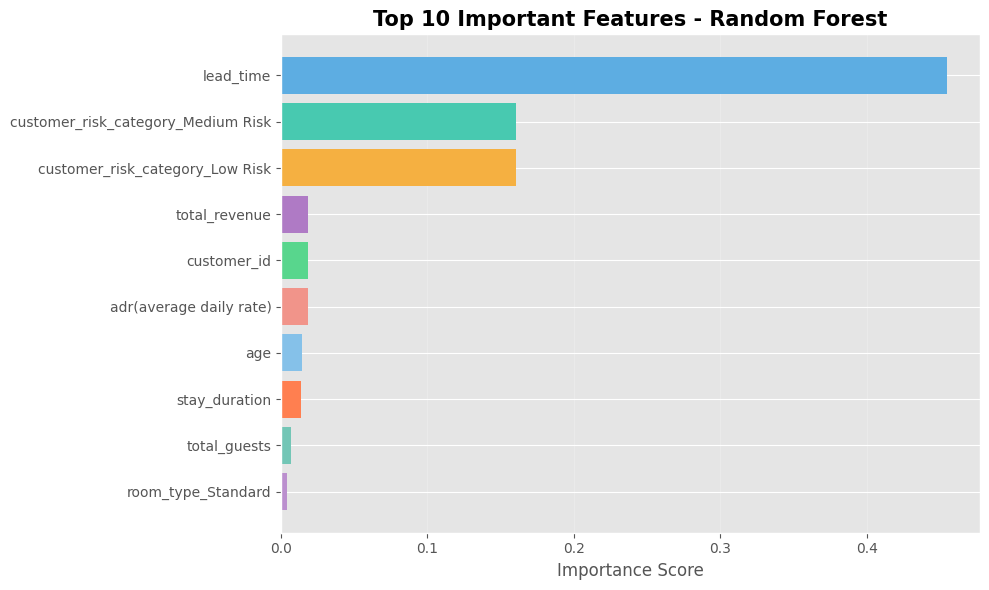

                                Feature  Importance
2                             lead_time    0.454698
380  customer_risk_category_Medium Risk    0.160784
379     customer_risk_category_Low Risk    0.160588
4                         total_revenue    0.018387
0                           customer_id    0.018299
3               adr(average daily rate)    0.018158
1                                   age    0.014377
6                         stay_duration    0.013357
5                          total_guests    0.006667
375                  room_type_Standard    0.003962


In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================
# FEATURE IMPORTANCE
# =========================================

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

# Sort features
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Top 10 features
top_features = importance_df.head(10)

# =========================================
# MULTI-COLOR BAR GRAPH
# =========================================

colors = [
    "#5DADE2",  # blue
    "#48C9B0",  # teal
    "#F5B041",  # orange
    "#AF7AC5",  # purple
    "#58D68D",  # green
    "#F1948A",  # pink
    "#85C1E9",  # sky blue
    "#FF7F50",  # coral
    "#73C6B6",  # mint
    "#BB8FCE"   # lavender
]

# Plot
plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"],
    color=colors
)

# Labels
plt.xlabel("Importance Score", fontsize=12)

plt.title(
    "Top 10 Important Features - Random Forest",
    fontsize=15,
    fontweight="bold"
)

# Highest value on top
plt.gca().invert_yaxis()

# Light grid
plt.grid(axis='x', alpha=0.2)

plt.tight_layout()

plt.show()

# =========================================
# DISPLAY VALUES
# =========================================

print(top_features)

Insight: This shows which features most influence cancellation prediction

# Limitations

# Future Scope

# Conclusion